In [1]:
# -----------------------------
# Imports & Setup
# -----------------------------
import sys
from pathlib import Path
import logging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import joblib

# Optional ensemble models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# -----------------------------
# Project Path Setup
# -----------------------------
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

# -----------------------------
# Custom Modules
# -----------------------------
from src.data.loader import FraudDataLoader
from src.modeling import ModelingPipeline, PipelineConfig
from src.utils.io_utils import save_dataframe

# -----------------------------
# Pandas & Seaborn Settings
# -----------------------------
pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid")

# -----------------------------
# Logging Setup
# -----------------------------
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("Modeling_Fraud")


In [2]:
# -----------------------------
# Load Processed Feature-Engineered Data
# -----------------------------
fraud_loader = FraudDataLoader("../data/processed/fraud_data_with_features.csv")
fraud_df = fraud_loader.load()

logger.info(f"Fraud data shape: {fraud_df.shape}")
logger.info(f"Fraud data columns: {fraud_df.columns}")

fraud_df.head()


2026-02-15 08:25:56,318 [INFO] Loaded file: ..\data\processed\fraud_data_with_features.csv with shape (151112, 17)
2026-02-15 08:25:56,458 [INFO] Fraud dataset validation complete
2026-02-15 08:25:56,459 [INFO] Fraud data shape: (151112, 17)
2026-02-15 08:25:56,460 [INFO] Fraud data columns: Index(['purchase_time', 'user_id', 'signup_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'country', 'hour_of_day', 'day_of_week', 'time_since_signup',
       'transactions_per_user', 'transactions_last_24h'],
      dtype='object')


,purchase_time,user_id,signup_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country,hour_of_day,day_of_week,time_since_signup,transactions_per_user,transactions_last_24h
0,2015-02-21 10:03:37,2,2015-01-11 03:47:13,54,FGBQNDNBETFJJ,SEO,Chrome,F,25,8.802175e+08,0,United States,10,5,990.273333,1,1.0
1,2015-09-26 21:32:16,4,2015-06-02 16:40:57,41,MKFUIVOHLJBYN,Direct,Safari,F,38,2.785906e+09,0,Switzerland,21,5,2788.855278,1,1.0
2,2015-08-13 11:53:07,8,2015-05-28 07:53:06,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,3.560567e+08,0,United States,11,3,1852.000278,1,1.0
3,2015-05-20 23:06:42,9,2015-05-16 15:58:32,62,IEZOHXPZBIRTE,SEO,FireFox,M,21,7.591047e+08,0,Unknown,23,2,103.136111,1,1.0
4,2015-03-04 20:56:37,12,2015-01-10 06:25:12,35,MSNWCFEHKTIOY,Ads,Safari,M,19,2.985180e+09,0,Mexico,20,2,1286.523611,1,1.0


In [3]:
# -----------------------------
# Features & Target
# -----------------------------
NUMERIC_FEATURES = [
    'purchase_value',
    'age',
    'hour_of_day',
    'day_of_week',
    'time_since_signup',
    'transactions_per_user',
    'transactions_last_24h'
]

CATEGORICAL_FEATURES = ['source', 'browser', 'sex', 'country']
TARGET = 'class'

config = PipelineConfig(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET,
    use_smote=True
)

pipeline = ModelingPipeline(
    df=fraud_df,
    config=config
)


2026-02-15 08:25:56,501 [INFO] Initialized pipeline with 151112 rows


2026-02-15 08:25:56,513 [INFO] Step 1: Preparing data...
2026-02-15 08:25:56,980 [INFO] Training shape: (120889, 196), Test shape: (30223, 196)


Training set: 120,889 samples
Test set: 30,223 samples

Training class distribution:
class
0    109568
1     11321
Name: count, dtype: int64

Test class distribution:
class
0    27393
1     2830
Name: count, dtype: int64


2026-02-15 08:25:57,204 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-15 08:25:57,277 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-15 08:25:57,346 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-15 08:25:57,370 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


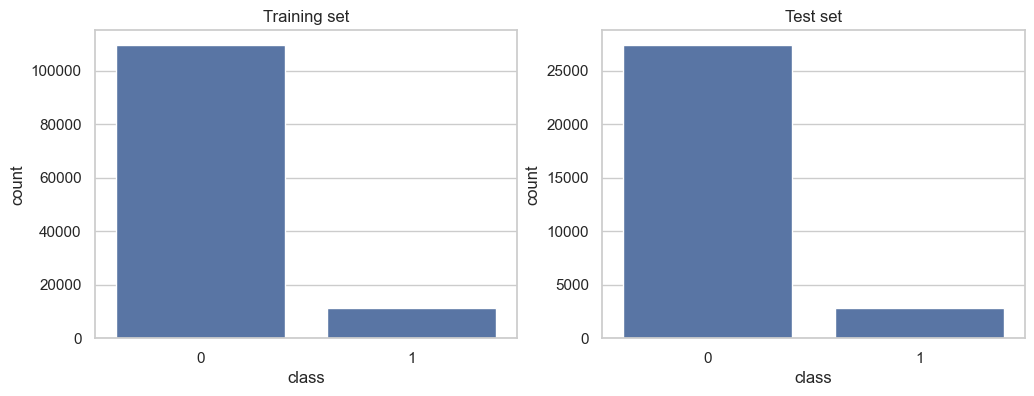

In [4]:
# -----------------------------
# Split, Scale & Encode
# -----------------------------
X_train, X_test, y_train, y_test = pipeline.prepare_data()

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

# Plot class distribution
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Training set")
plt.subplot(1,2,2)
sns.countplot(x=y_test)
plt.title("Test set")
plt.show()


In [5]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = cm.sum()
    cm_percent = cm / cm_sum * 100
    labels = np.array([["{} ({:.1f}%)".format(val, pct) 
                        for val, pct in zip(row_val, row_pct)]
                       for row_val, row_pct in zip(cm, cm_percent)])
    
    fig, ax = plt.subplots(figsize=(6,6))
    cax = ax.matshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i,j] > cm.max()/2 else "black"
            ax.text(j, i, labels[i,j], va='center', ha='center', color=color, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks(range(cm.shape[0]))
    ax.set_yticks(range(cm.shape[1]))
    plt.title(title, pad=20)
    plt.show()

def plot_precision_recall_curve_model(model, X_test, y_test, title="Precision-Recall Curve"):
    y_prob = model.predict_proba(X_test)[:,1]
    PrecisionRecallDisplay.from_predictions(y_test, y_prob)
    plt.title(title)
    plt.show()

def plot_roc_curve_model(model, X_test, y_test, title="ROC Curve"):
    y_prob = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(title)
    plt.show()

def plot_model_comparison_barplot(models, model_names, X_test, y_test):
    """
    Plots a barplot comparing Precision, Recall, and F1-score for all models on class 1 (fraud)
    """
    metrics_summary = []

    for model, name in zip(models, model_names):
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        metrics_summary.append({
            "Model": name,
            "Precision": report['1']['precision'],
            "Recall": report['1']['recall'],
            "F1-Score": report['1']['f1-score']
        })

    metrics_df = pd.DataFrame(metrics_summary)
    metrics_df = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(10,6))
    sns.barplot(x="Model", y="Score", hue="Metric", data=metrics_df)
    plt.title("Model Comparison — Key Metrics (Class 1: Fraud)")
    plt.ylim(0,1)
    plt.legend(loc="lower right")
    plt.show()


2026-02-15 08:25:57,559 [INFO] Training Logistic Regression...


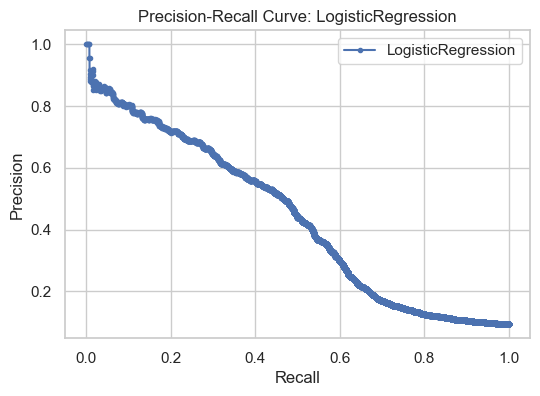

2026-02-15 08:26:57,977 [INFO] Running Stratified 5-Fold CV...
2026-02-15 08:27:07,512 [INFO] Logistic Regression best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
2026-02-15 08:27:07,524 [INFO] Evaluating Logistic Regression...


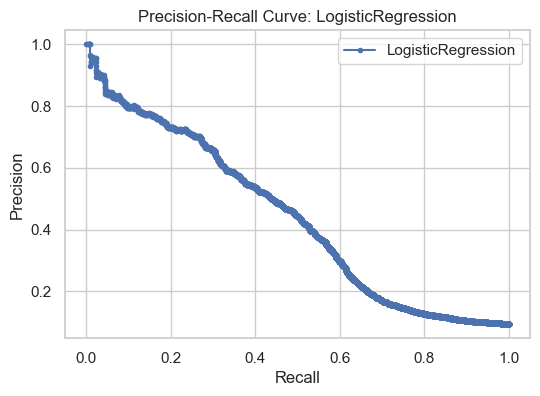

AUC_PR: 0.438
F1: 0.275
Precision: 0.171
Recall: 0.699


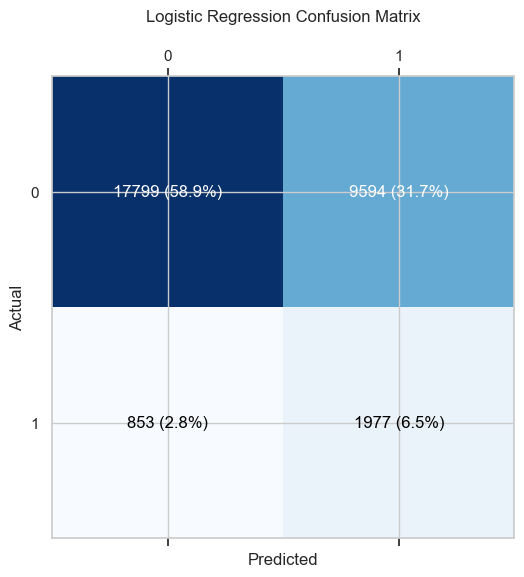

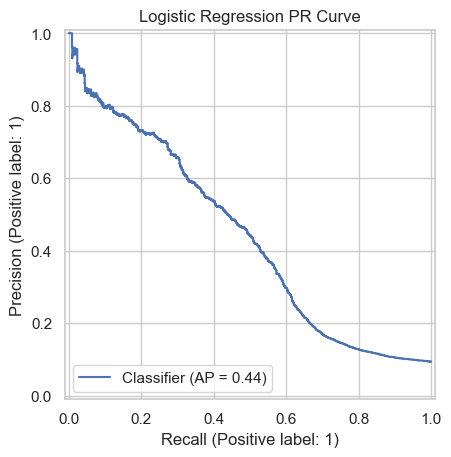

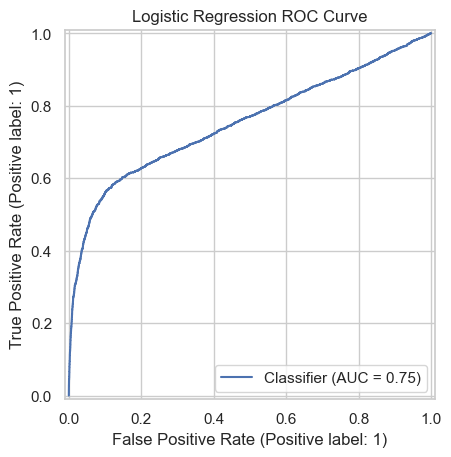

In [6]:
logger.info("Training Logistic Regression...")
lr_model = pipeline.tune_and_train_logistic_regression()

logger.info("Evaluating Logistic Regression...")
metrics = pipeline.evaluate(lr_model)
for k,v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

plot_confusion_matrix(y_test, lr_model.predict(X_test), title="Logistic Regression Confusion Matrix")
plot_precision_recall_curve_model(lr_model, X_test, y_test, title="Logistic Regression PR Curve")
plot_roc_curve_model(lr_model, X_test, y_test, title="Logistic Regression ROC Curve")


2026-02-15 08:27:07,995 [INFO] Training Random Forest...


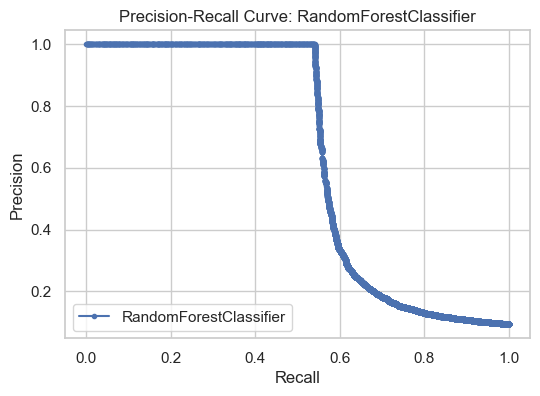

2026-02-15 08:27:18,130 [INFO] Running Stratified 5-Fold CV...
2026-02-15 08:28:10,500 [INFO] Evaluating Random Forest...


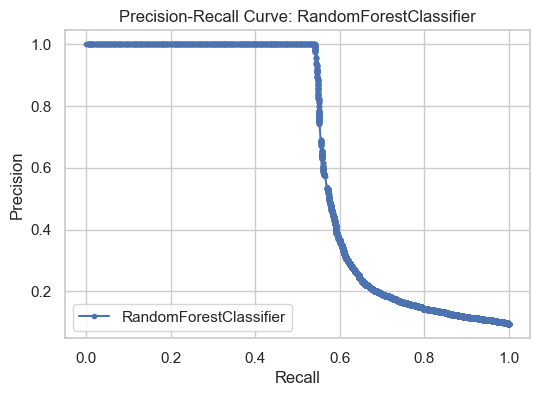

AUC_PR: 0.640
F1: 0.701
Precision: 0.994
Recall: 0.541


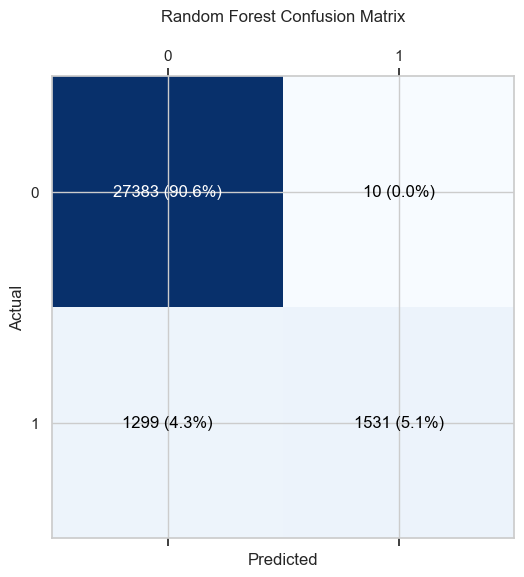

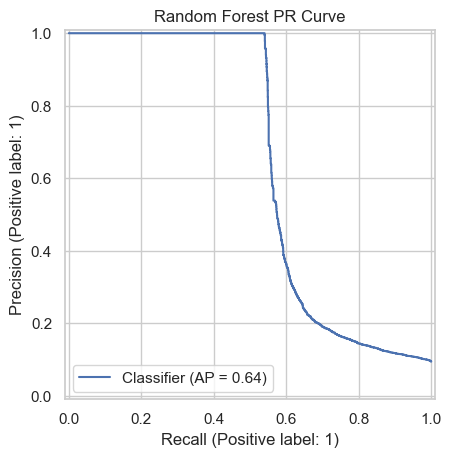

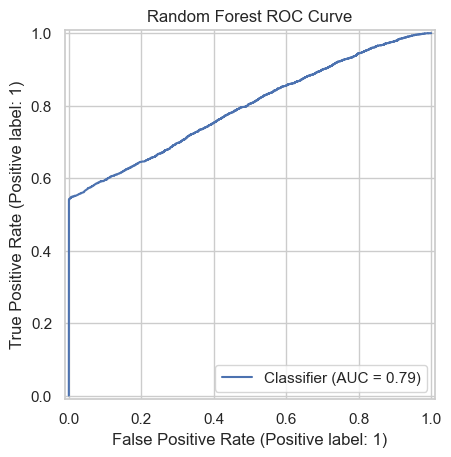

In [7]:
logger.info("Training Random Forest...")
rf_model = pipeline.train_random_forest()

logger.info("Evaluating Random Forest...")
metrics = pipeline.evaluate(rf_model)
for k,v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

plot_confusion_matrix(y_test, rf_model.predict(X_test), title="Random Forest Confusion Matrix")
plot_precision_recall_curve_model(rf_model, X_test, y_test, title="Random Forest PR Curve")
plot_roc_curve_model(rf_model, X_test, y_test, title="Random Forest ROC Curve")


2026-02-15 08:28:11,378 [INFO] Training XGBoost using ModelingPipeline...
2026-02-15 08:28:11,379 [INFO] Step 1: Preparing data...
2026-02-15 08:28:11,670 [INFO] Training shape: (120889, 196), Test shape: (30223, 196)
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:28:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


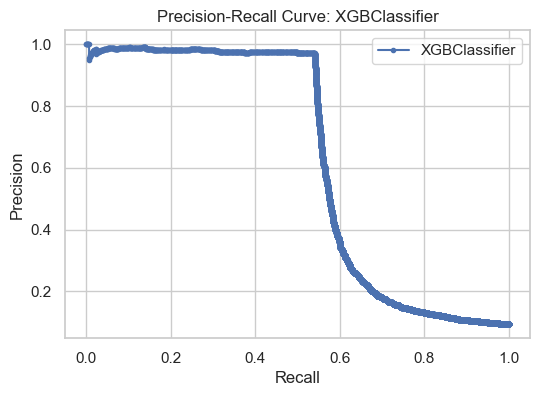

2026-02-15 08:28:21,251 [INFO] Running Stratified 5-Fold CV...
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:28:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:28:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:28:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\amare\Documents\KAIM\w

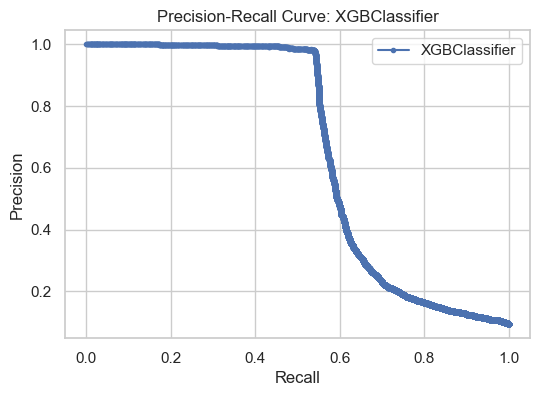

AUC_PR: 0.655
F1: 0.695
Precision: 0.969
Recall: 0.542


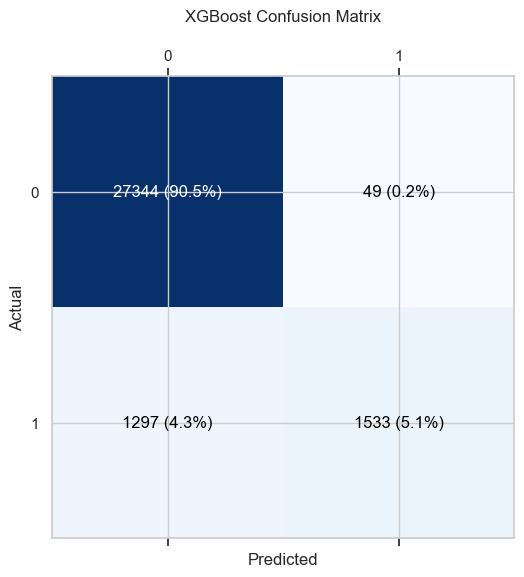

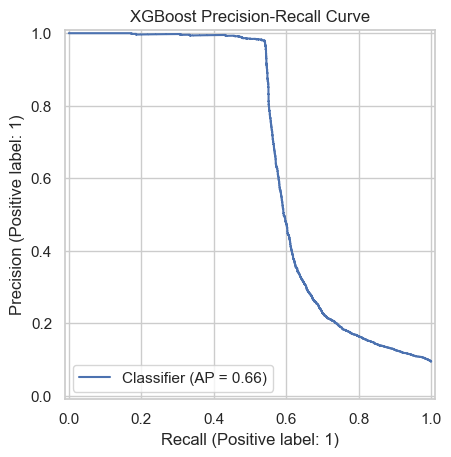

In [8]:


logger.info("Training XGBoost using ModelingPipeline...")

# Ensure data is prepared
pipeline.prepare_data()

# Train XGBoost via pipeline
xgb_model = pipeline.train_xgboost(
    params={
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "random_state": 42
    }
)

# Evaluation metrics already computed inside pipeline,
# but we can re-run evaluation explicitly if needed
metrics = pipeline.evaluate(xgb_model)

for k, v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

# Confusion Matrix
plot_confusion_matrix(
    pipeline.y_test,
    xgb_model.predict(pipeline.X_test),
    title="XGBoost Confusion Matrix"
)

# Precision-Recall Curve
plot_precision_recall_curve_model(
    xgb_model,
    pipeline.X_test,
    pipeline.y_test,
    title="XGBoost Precision-Recall Curve"
)


2026-02-15 08:29:07,344 [INFO] Training LightGBM using ModelingPipeline...
2026-02-15 08:29:07,345 [INFO] Step 1: Preparing data...
2026-02-15 08:29:07,671 [INFO] Training shape: (120889, 196), Test shape: (30223, 196)


[LightGBM] [Info] Number of positive: 109568, number of negative: 109568
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044010 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12209
[LightGBM] [Info] Number of data points in the train set: 219136, number of used features: 121
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

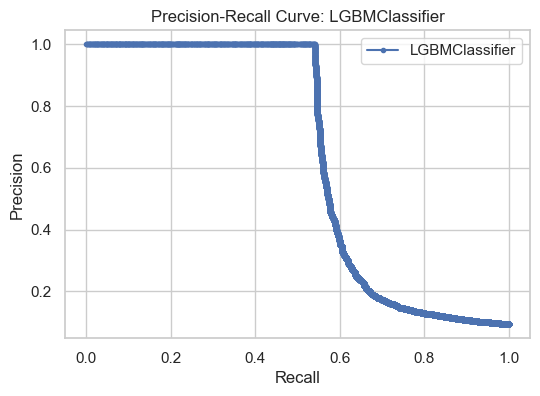

2026-02-15 08:29:10,896 [INFO] Running Stratified 5-Fold CV...


[LightGBM] [Info] Number of positive: 109568, number of negative: 109568
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046785 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12192
[LightGBM] [Info] Number of data points in the train set: 219136, number of used features: 123
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

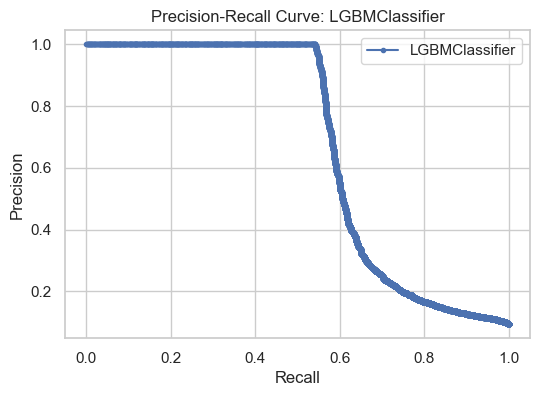

AUC_PR: 0.668
F1: 0.702
Precision: 1.000
Recall: 0.540


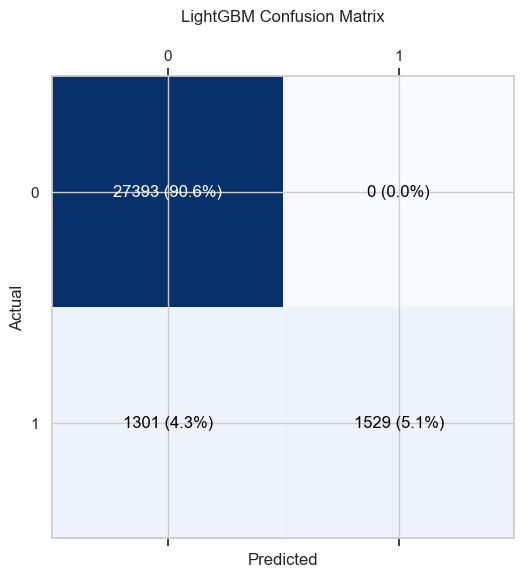

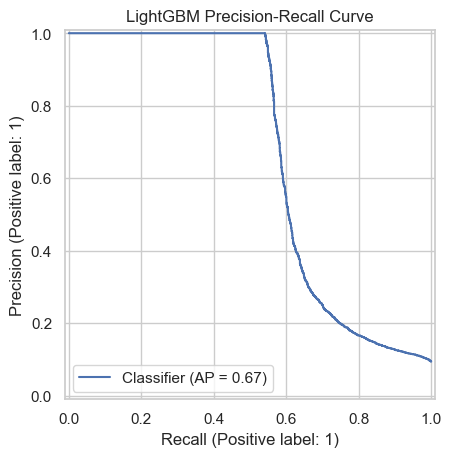

In [9]:
logger.info("Training LightGBM using ModelingPipeline...")

# Ensure data is prepared (remove if already called earlier)
pipeline.prepare_data()

# Train LightGBM via pipeline
lgbm_model = pipeline.train_lightgbm(
    params={
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "random_state": 42
    }
)

# Optional: re-evaluate explicitly (already done internally)
metrics = pipeline.evaluate(lgbm_model)

for k, v in metrics.items():
    if k != "ConfusionMatrix":
        print(f"{k}: {v:.3f}")

# Confusion Matrix
plot_confusion_matrix(
    pipeline.y_test,
    lgbm_model.predict(pipeline.X_test),
    title="LightGBM Confusion Matrix"
)

# Precision-Recall Curve
plot_precision_recall_curve_model(
    lgbm_model,
    pipeline.X_test,
    pipeline.y_test,
    title="LightGBM Precision-Recall Curve"
)


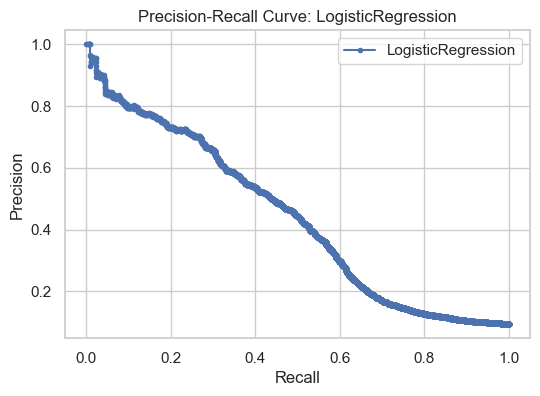

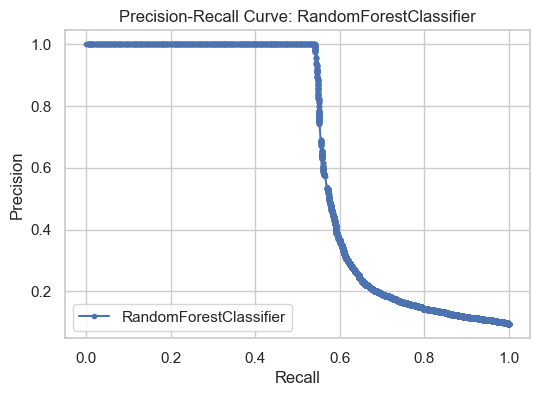

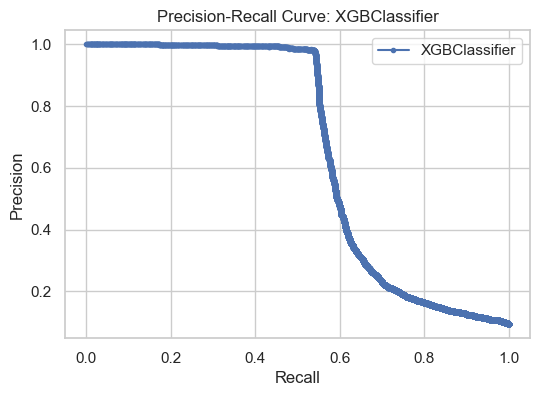

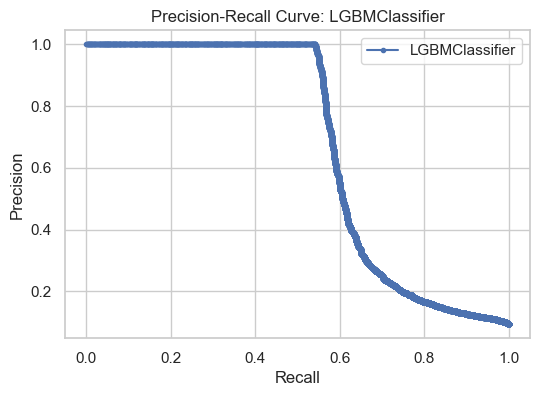

,Model,AUC_PR,F1,Precision,Recall,ConfusionMatrix
0,Logistic Regression,0.437713,0.274564,0.170858,0.698587,"[[17799, 9594], [853, 1977]]"
1,Random Forest,0.640196,0.700526,0.993511,0.540989,"[[27383, 10], [1299, 1531]]"
2,XGBoost,0.655025,0.694923,0.969027,0.541696,"[[27344, 49], [1297, 1533]]"
3,LightGBM,0.667715,0.701537,1.000000,0.540283,"[[27393, 0], [1301, 1529]]"


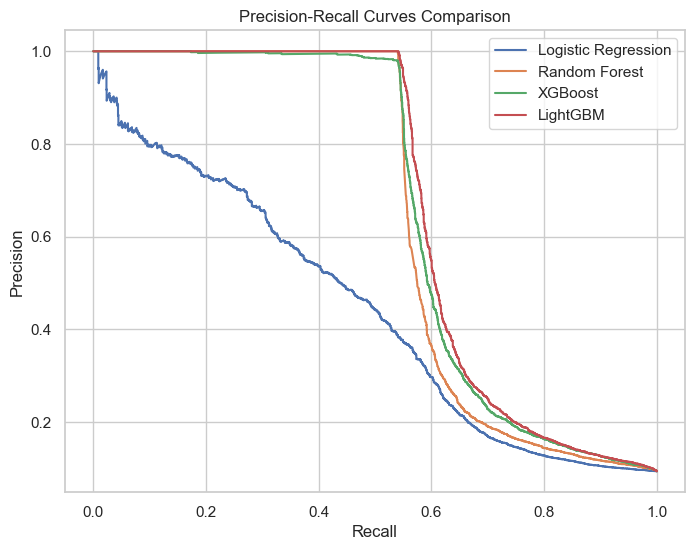

In [10]:
all_models = [lr_model, rf_model, xgb_model, lgbm_model]
all_model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]

comparison_list = []
for model, name in zip(all_models, all_model_names):
    metrics = pipeline.evaluate(model)
    comparison_list.append({"Model": name, **metrics})

comparison_df = pd.DataFrame(comparison_list)
display(comparison_df)

# Plot side-by-side PR curves
plt.figure(figsize=(8,6))
for model, name in zip(all_models, all_model_names):
    y_prob = model.predict_proba(X_test)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Comparison")
plt.legend()
plt.show()



Classification Report — Logistic Regression


,precision,recall,f1-score,support
0,0.954268,0.649765,0.773113,27393.000000
1,0.170858,0.698587,0.274564,2830.000000
accuracy,0.654336,0.654336,0.654336,0.654336
macro avg,0.562563,0.674176,0.523839,30223.000000
weighted avg,0.880911,0.654336,0.726430,30223.000000



Classification Report — Random Forest


,precision,recall,f1-score,support
0,0.954710,0.999635,0.976656,27393.000000
1,0.993511,0.540989,0.700526,2830.000000
accuracy,0.956689,0.956689,0.956689,0.956689
macro avg,0.974110,0.770312,0.838591,30223.000000
weighted avg,0.958343,0.956689,0.950800,30223.000000



Classification Report — XGBoost


,precision,recall,f1-score,support
0,0.954715,0.998211,0.975979,27393.000000
1,0.969027,0.541696,0.694923,2830.000000
accuracy,0.955464,0.955464,0.955464,0.955464
macro avg,0.961871,0.769954,0.835451,30223.000000
weighted avg,0.956055,0.955464,0.949662,30223.000000



Classification Report — LightGBM


,precision,recall,f1-score,support
0,0.954660,1.000000,0.976804,27393.000000
1,1.000000,0.540283,0.701537,2830.000000
accuracy,0.956953,0.956953,0.956953,0.956953
macro avg,0.977330,0.770141,0.839170,30223.000000
weighted avg,0.958905,0.956953,0.951029,30223.000000


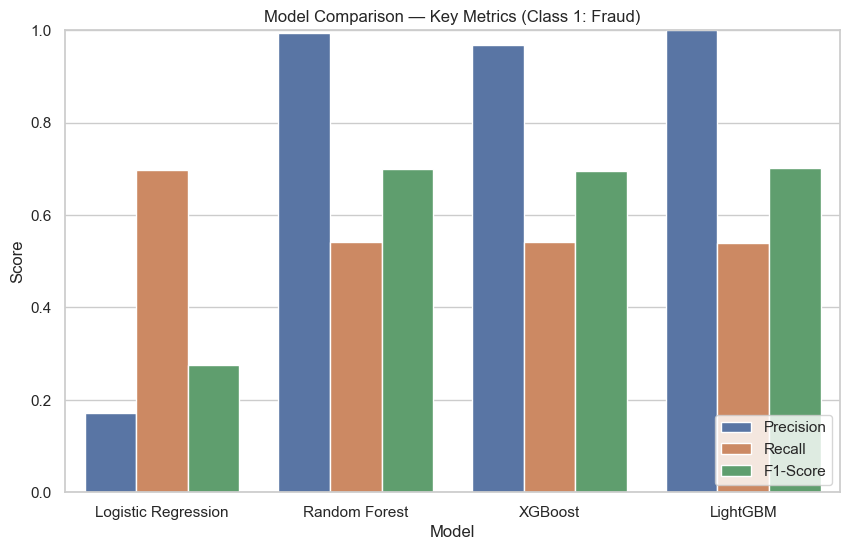

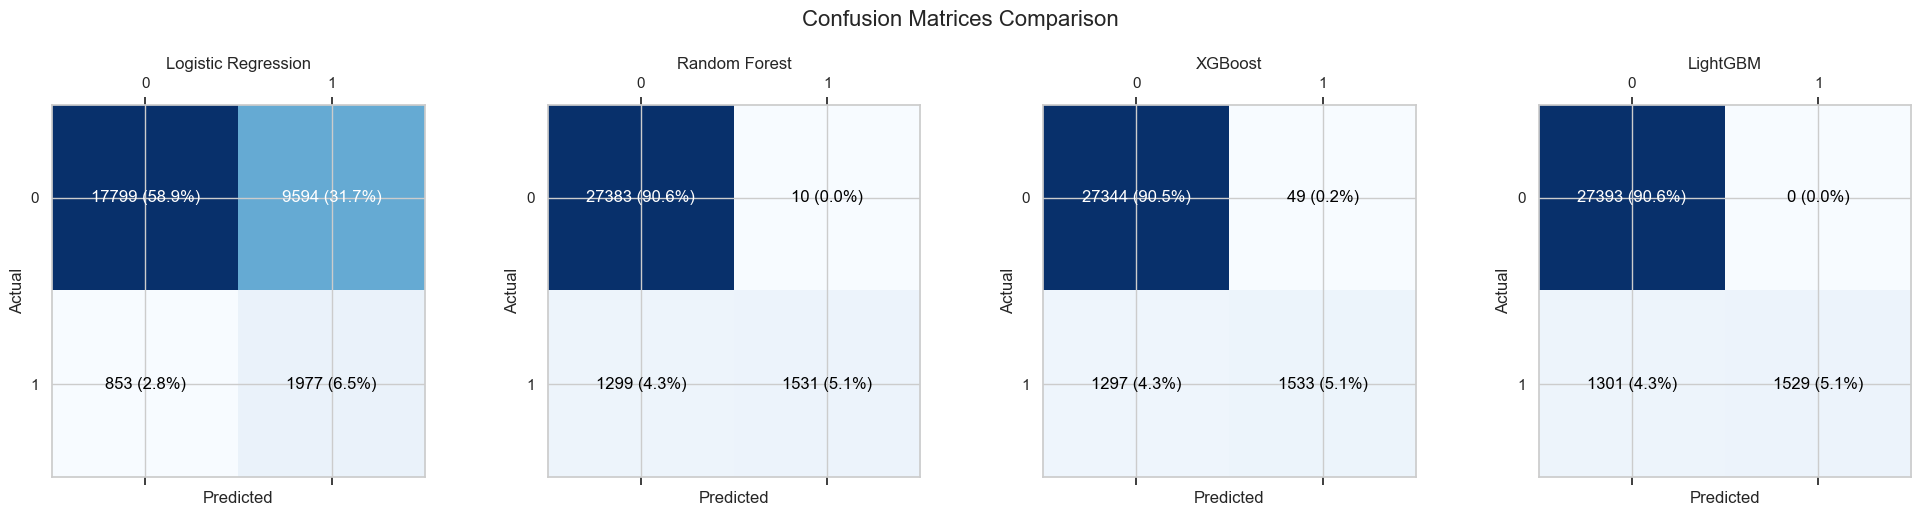

In [11]:
all_models = [lr_model, rf_model, xgb_model, lgbm_model]
all_model_names = ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]

# Classification reports
all_class_reports = {}
for model, name in zip(all_models, all_model_names):
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    all_class_reports[name] = report
    print(f"\nClassification Report — {name}")
    display(pd.DataFrame(report).transpose())

# Barplot of key metrics
plot_model_comparison_barplot(all_models, all_model_names, X_test, y_test)

# Combined confusion matrices
fig, axes = plt.subplots(1, len(all_models), figsize=(20,5))
for ax, model, name in zip(axes, all_models, all_model_names):
    cm = confusion_matrix(y_test, model.predict(X_test))
    cm_sum = cm.sum()
    cm_percent = cm / cm_sum * 100
    labels = np.array([["{} ({:.1f}%)".format(val, pct) 
                        for val, pct in zip(row_val, row_pct)]
                       for row_val, row_pct in zip(cm, cm_percent)])
    ax.matshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i,j] > cm.max()/2 else "black"
            ax.text(j, i, labels[i,j], va='center', ha='center', color=color, fontsize=12)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(cm.shape[0]))
    ax.set_yticks(range(cm.shape[1]))
plt.suptitle("Confusion Matrices Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [12]:
best_model_info, justification = pipeline.select_best_model()
display(best_model_info)
print("\nJustification:", justification)

# Save models and preprocessor
models_dir = Path.cwd().parent / "models"
models_dir.mkdir(exist_ok=True)

best_model_name = best_model_info["Model"]
best_model = {"Logistic Regression": lr_model,
              "Random Forest": rf_model,
              "XGBoost": xgb_model,
              "LightGBM": lgbm_model}[best_model_name]

model_filename = models_dir / f"{best_model_name.replace(' ','_').lower()}_fraud.joblib"
joblib.dump(best_model, model_filename)
print(f"Saved best model: {model_filename}")

preprocessor_filename = models_dir / "preprocessor_fraud.joblib"
joblib.dump(pipeline.preprocessor, preprocessor_filename)
print(f"Saved preprocessor: {preprocessor_filename}")


2026-02-15 08:29:32,216 [INFO] Comparing models...
2026-02-15 08:29:32,219 [INFO] Random Forest selected due to highest AUC-PR (0.635) and strong recall, prioritizing undetected fraud reduction while maintaining interpretability.


Model                           Random Forest
AUC_PR                               0.634536
F1                                   0.700412
Precision                            0.995443
Recall                               0.540283
ConfusionMatrix    [[27386, 7], [1301, 1529]]
F1_mean                              0.695854
F1_std                               0.013143
AUC_PR_mean                          0.630247
AUC_PR_std                           0.014102
Name: 0, dtype: object


Justification: Random Forest selected due to highest AUC-PR (0.635) and strong recall, prioritizing undetected fraud reduction while maintaining interpretability.
Saved best model: c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\models\random_forest_fraud.joblib
Saved preprocessor: c:\Users\amare\Documents\KAIM\week5-6\financial-fraud-detection\models\preprocessor_fraud.joblib
